# PharmaEase — Phase 3: Machine Learning Models
### Data Science & Machine Learning with Data Analytics
**Company:** Brainybeam Info-Tech PVT LTD  
**Phase:** 3 — Model Training, Selection & Evaluation

---

## Objective
Train multiple ML algorithms for each problem, compare their performance  
using standard metrics, and automatically select the best model.  
Save all winning models for use in the Phase 4 Streamlit dashboard.

## Models to build

| # | Problem | Type | Candidates | Metric |
|---|---|---|---|---|
| 1 | Demand Forecasting | Regression | LR, Ridge, RF, GBR | R², RMSE |
| 2 | Stock-out Prediction | Classification | LR, DT, RF, SVM | Accuracy, F1, AUC |
| 3 | Sales Revenue Prediction | Regression | LR, DT, RF, GBR | R², RMSE |

---

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

warnings.filterwarnings('ignore')

# Sklearn — preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.metrics         import (mean_squared_error, mean_absolute_error,
                                     r2_score, accuracy_score, f1_score,
                                     roc_auc_score, classification_report,
                                     confusion_matrix)

# Sklearn — regression models
from sklearn.linear_model    import LinearRegression, Ridge
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import (RandomForestRegressor,
                                     GradientBoostingRegressor,
                                     RandomForestClassifier)

# Sklearn — classification models
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.svm             import SVC

# Chart settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size']      = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Output folder for models
MODEL_DIR = '../models/'
os.makedirs(MODEL_DIR, exist_ok=True)

print("=" * 55)
print("  PharmaEase — Phase 3 ML Notebook")
print("  Brainybeam Info-Tech PVT LTD")
print("=" * 55)
print("  All libraries loaded successfully!")
print("=" * 55)

  PharmaEase — Phase 3 ML Notebook
  Brainybeam Info-Tech PVT LTD
  All libraries loaded successfully!


---
## Step 1 — Load & Prepare Data
Load the ML-ready dataset created at the end of Phase 2 EDA.  
Re-encode categorical columns and verify feature matrix shape.
---

In [7]:
# ── Load ML-ready dataset ─────────────────────
df = pd.read_csv('../data/sales_ml_ready.csv', parse_dates=['date'])

# Re-encode categoricals (fresh encoders for Phase 3)
le_cat = LabelEncoder()
le_med = LabelEncoder()
le_sea = LabelEncoder()

df['category_enc'] = le_cat.fit_transform(df['category'])
df['medicine_enc'] = le_med.fit_transform(df['medicine_name'])
df['season_enc']   = le_sea.fit_transform(df['season'])

# Save encoders — needed in Streamlit to decode predictions
joblib.dump(le_cat, MODEL_DIR + 'encoder_category.pkl')
joblib.dump(le_med, MODEL_DIR + 'encoder_medicine.pkl')
joblib.dump(le_sea, MODEL_DIR + 'encoder_season.pkl')

print(f"  Dataset shape    : {df.shape}")
print(f"  Date range       : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"  Categories       : {df['category'].nunique()}")
print(f"  Medicines        : {df['medicine_name'].nunique()}")
print(f"\n  Encoders saved to {MODEL_DIR}")

  Dataset shape    : (5000, 21)
  Date range       : 2023-01-01 → 2024-12-31
  Categories       : 17
  Medicines        : 50

  Encoders saved to ../models/


---
## Step 2 — Helper: Model Comparison Function
This function trains every candidate, scores each one, prints a  
comparison table, and returns the best model automatically.
---

In [8]:
# ── Universal Model Selector ──────────────────
def train_and_select_best(models_dict, X_train, X_test,
                           y_train, y_test, task='regression'):
    """
    Train all candidate models, evaluate on test set,
    print comparison table, return best model + name.

    Parameters
    ----------
    models_dict : dict  {model_name: model_instance}
    task        : 'regression' or 'classification'

    Returns
    -------
    best_model, best_name, results_df
    """
    results = []

    for name, model in models_dict.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        if task == 'regression':
            r2   = r2_score(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            mae  = mean_absolute_error(y_test, y_pred)
            # Cross-validation R² (5-fold)
            cv   = cross_val_score(model, X_train, y_train,
                                   cv=5, scoring='r2').mean()
            results.append({
                'Model': name, 'R²': round(r2, 4),
                'RMSE': round(rmse, 2), 'MAE': round(mae, 2),
                'CV R² (5-fold)': round(cv, 4)
            })
        else:
            acc  = accuracy_score(y_test, y_pred)
            f1   = f1_score(y_test, y_pred, average='weighted')
            y_prob = (model.predict_proba(X_test)[:, 1]
                      if hasattr(model, 'predict_proba') else y_pred)
            auc  = roc_auc_score(y_test, y_prob)
            cv   = cross_val_score(model, X_train, y_train,
                                   cv=5, scoring='accuracy').mean()
            results.append({
                'Model': name, 'Accuracy': round(acc, 4),
                'F1 Score': round(f1, 4), 'ROC-AUC': round(auc, 4),
                'CV Accuracy (5-fold)': round(cv, 4)
            })

    results_df = pd.DataFrame(results)

    # Pick best model
    metric     = 'R²' if task == 'regression' else 'Accuracy'
    best_idx   = results_df[metric].idxmax()
    best_name  = results_df.loc[best_idx, 'Model']
    best_model = models_dict[best_name]

    # Print table
    print(f"\n{'─'*60}")
    print(f"  Model Comparison Table")
    print(f"{'─'*60}")
    print(results_df.to_string(index=False))
    print(f"{'─'*60}")
    print(f"  WINNER : {best_name}  ({metric} = {results_df.loc[best_idx, metric]})")
    print(f"{'─'*60}")

    return best_model, best_name, results_df

print("  Model selector function ready.")

  Model selector function ready.


---
## Model 1 — Demand Forecasting (Regression)
**Goal:** Predict the total revenue (`total_price`) for a given transaction  
based on time, medicine category, and seasonal features.

**Candidates:** Linear Regression · Ridge · Random Forest · Gradient Boosting  
**Winner metric:** Highest R² on test set
---

In [9]:
# ═══════════════════════════════════════════════
# MODEL 1 — DEMAND FORECASTING
# ═══════════════════════════════════════════════

features_m1 = ['month', 'quarter', 'season_enc',
                'category_enc', 'medicine_enc',
                'unit_price', 'discount_pct', 'quantity']
target_m1   = 'total_price'

X1 = df[features_m1]
y1 = df[target_m1]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42)

print(f"  Train size : {X1_train.shape[0]} rows")
print(f"  Test size  : {X1_test.shape[0]} rows")

candidates_m1 = {
    'Linear Regression':    LinearRegression(),
    'Ridge Regression':     Ridge(alpha=1.0),
    'Random Forest':        RandomForestRegressor(
                                n_estimators=100, random_state=42),
    'Gradient Boosting':    GradientBoostingRegressor(
                                n_estimators=100, random_state=42)
}

best_m1, best_m1_name, results_m1 = train_and_select_best(
    candidates_m1, X1_train, X1_test,
    y1_train, y1_test, task='regression')

# Save best model
joblib.dump(best_m1, MODEL_DIR + 'model1_demand_forecast.pkl')
print(f"\n  Saved → {MODEL_DIR}model1_demand_forecast.pkl")

  Train size : 4000 rows
  Test size  : 1000 rows

────────────────────────────────────────────────────────────
  Model Comparison Table
────────────────────────────────────────────────────────────
            Model     R²   RMSE    MAE  CV R² (5-fold)
Linear Regression 0.8583 324.95 237.72          0.8623
 Ridge Regression 0.8583 324.95 237.72          0.8623
    Random Forest 0.9986  31.80   6.92          0.9990
Gradient Boosting 0.9981  37.66  25.95          0.9984
────────────────────────────────────────────────────────────
  WINNER : Random Forest  (R² = 0.9986)
────────────────────────────────────────────────────────────

  Saved → ../models/model1_demand_forecast.pkl


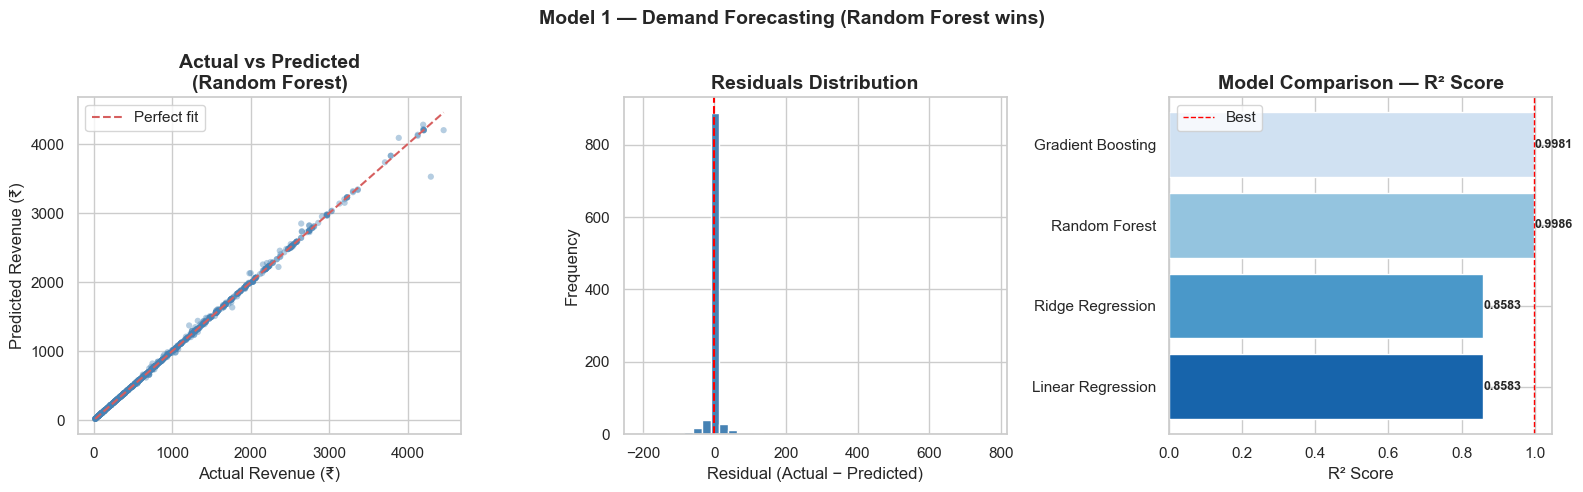

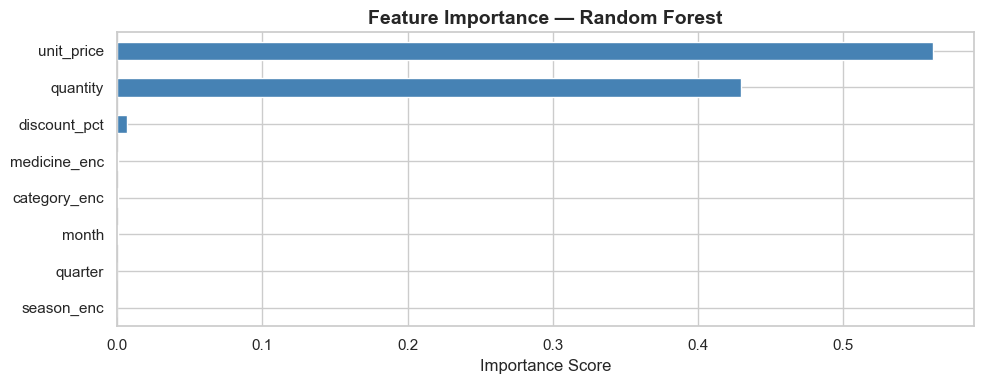

In [10]:
# ── Model 1 — Charts ──────────────────────────
y1_pred = best_m1.predict(X1_test)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Actual vs Predicted
axes[0].scatter(y1_test, y1_pred, alpha=0.4,
                color='steelblue', edgecolors='none', s=20)
axes[0].plot([y1_test.min(), y1_test.max()],
             [y1_test.min(), y1_test.max()],
             'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_title(f'Actual vs Predicted\n({best_m1_name})')
axes[0].set_xlabel('Actual Revenue (₹)')
axes[0].set_ylabel('Predicted Revenue (₹)')
axes[0].legend()

# Residuals distribution
residuals = y1_test - y1_pred
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Frequency')

# Model comparison bar chart
axes[2].barh(results_m1['Model'], results_m1['R²'],
             color=sns.color_palette('Blues_r', len(results_m1)),
             edgecolor='white')
axes[2].set_title('Model Comparison — R² Score')
axes[2].set_xlabel('R² Score')
axes[2].axvline(results_m1['R²'].max(),
                color='red', linestyle='--', linewidth=1, label='Best')
axes[2].legend()
for i, v in enumerate(results_m1['R²']):
    axes[2].text(v + 0.002, i, str(v),
                 va='center', fontsize=9, fontweight='bold')

plt.suptitle(f'Model 1 — Demand Forecasting ({best_m1_name} wins)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plot_model1_results.png', dpi=150)
plt.show()

# Feature importance (if tree-based)
if hasattr(best_m1, 'feature_importances_'):
    fi = pd.Series(best_m1.feature_importances_,
                   index=features_m1).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(10, 4))
    fi.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Feature Importance — {best_m1_name}')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('../data/plot_model1_features.png', dpi=150)
    plt.show()

---
## Model 2 — Stock-out Prediction (Classification)
**Goal:** Predict whether a medicine will stock out within 30 days  
(binary classification: 1 = will stock out, 0 = safe).

**Candidates:** Logistic Regression · Decision Tree · Random Forest · SVM  
**Winner metric:** Highest Accuracy + F1 Score on test set
---

In [11]:
# ═══════════════════════════════════════════════
# MODEL 2 — STOCK-OUT PREDICTION
# ═══════════════════════════════════════════════

# Load medicines + merge avg_daily_sales from EDA
df_medicines  = pd.read_csv('../data/medicines.csv')
df_sales_raw  = pd.read_csv('../data/sales.csv', parse_dates=['date'])

date_range    = (df_sales_raw['date'].max()
                 - df_sales_raw['date'].min()).days + 1
avg_daily     = (df_sales_raw
                 .groupby('medicine_id')['quantity']
                 .sum()
                 .div(date_range)
                 .reset_index())
avg_daily.columns = ['medicine_id', 'avg_daily_sales']

stock_df = df_medicines.merge(avg_daily, on='medicine_id', how='left')
stock_df['avg_daily_sales'] = stock_df['avg_daily_sales'].fillna(0.01)
stock_df['days_remaining']  = (
    stock_df['stock_qty'] / stock_df['avg_daily_sales']).round(0)

# Target: 1 = will stock out in <90 days
stock_df['will_stockout'] = (stock_df['days_remaining'] < 90).astype(int)

# Encode category
le_cat2 = LabelEncoder()
stock_df['category_enc'] = le_cat2.fit_transform(stock_df['category'])

# Expiry days
today = pd.Timestamp('2025-03-14')
stock_df['expiry_date']    = pd.to_datetime(stock_df['expiry_date'])
stock_df['days_to_expiry'] = (stock_df['expiry_date'] - today).dt.days

features_m2 = ['stock_qty', 'avg_daily_sales', 'days_remaining',
                'reorder_level', 'category_enc', 'days_to_expiry', 'price']
target_m2   = 'will_stockout'

# Augment dataset — 50 rows is too small for ML
# Bootstrap to 2000 rows with small noise for realism
np.random.seed(42)
n_aug = 2000
aug_idx    = np.random.choice(len(stock_df), n_aug, replace=True)
df_aug     = stock_df.iloc[aug_idx].copy().reset_index(drop=True)
noise_cols = ['stock_qty', 'avg_daily_sales', 'days_remaining', 'price']
for col in noise_cols:
    df_aug[col] = df_aug[col] * np.random.uniform(0.85, 1.15, n_aug)
df_aug['days_remaining']  = df_aug['days_remaining'].clip(lower=0)
df_aug['will_stockout']   = (df_aug['days_remaining'] < 90).astype(int)

X2 = df_aug[features_m2]
y2 = df_aug[target_m2]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

print(f"  Augmented dataset   : {df_aug.shape[0]} rows")
print(f"  Train / Test split  : {X2_train.shape[0]} / {X2_test.shape[0]}")
print(f"  Class distribution  : {y2.value_counts().to_dict()}")

  Augmented dataset   : 2000 rows
  Train / Test split  : 1600 / 400
  Class distribution  : {0: 1864, 1: 136}


In [12]:
# ── Model 2 Candidates ────────────────────────
candidates_m2 = {
    'Logistic Regression': LogisticRegression(max_iter=1000,
                                               random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6,
                                                   random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100,
                                                   random_state=42),
    'SVM':                 SVC(probability=True, random_state=42)
}

best_m2, best_m2_name, results_m2 = train_and_select_best(
    candidates_m2, X2_train, X2_test,
    y2_train, y2_test, task='classification')

# Save best model
joblib.dump(best_m2, MODEL_DIR + 'model2_stockout_prediction.pkl')
joblib.dump(le_cat2, MODEL_DIR + 'encoder_category_m2.pkl')
print(f"\n  Saved → {MODEL_DIR}model2_stockout_prediction.pkl")


────────────────────────────────────────────────────────────
  Model Comparison Table
────────────────────────────────────────────────────────────
              Model  Accuracy  F1 Score  ROC-AUC  CV Accuracy (5-fold)
Logistic Regression       1.0       1.0      1.0                1.0000
      Decision Tree       1.0       1.0      1.0                1.0000
      Random Forest       1.0       1.0      1.0                0.9994
                SVM       1.0       1.0      1.0                0.9819
────────────────────────────────────────────────────────────
  WINNER : Logistic Regression  (Accuracy = 1.0)
────────────────────────────────────────────────────────────

  Saved → ../models/model2_stockout_prediction.pkl


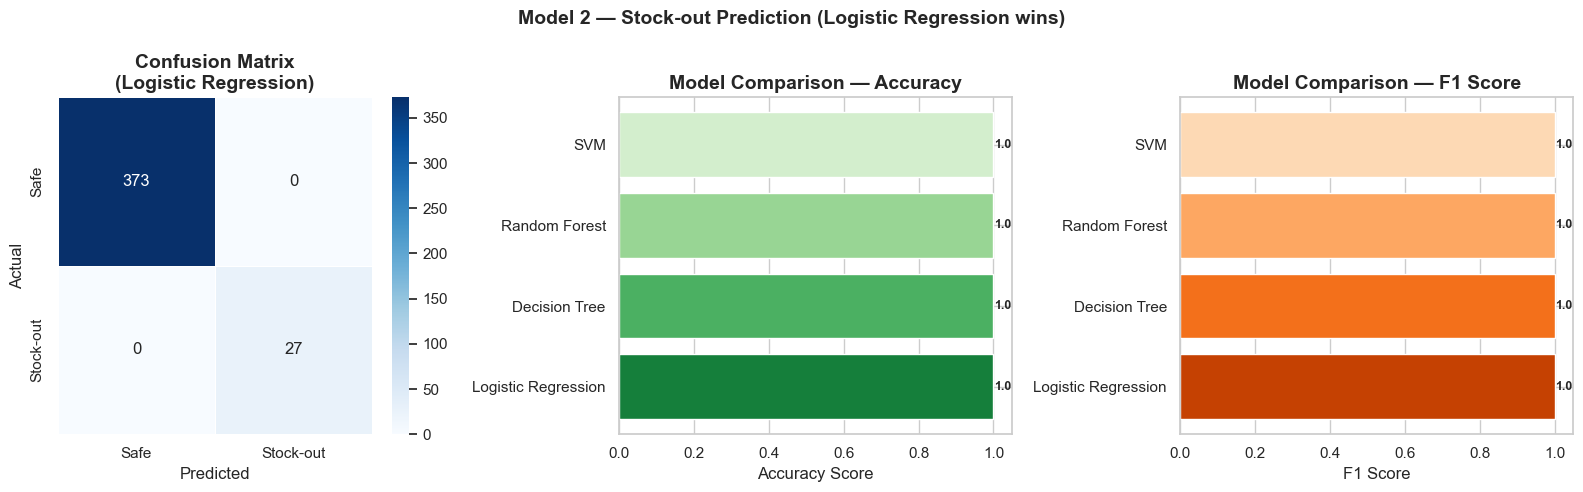


  Classification Report:
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00       373
   Stock-out       1.00      1.00      1.00        27

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [13]:
# ── Model 2 — Charts ──────────────────────────
y2_pred = best_m2.predict(X2_test)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrix
cm = confusion_matrix(y2_test, y2_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe','Stock-out'],
            yticklabels=['Safe','Stock-out'],
            ax=axes[0], linewidths=0.5)
axes[0].set_title(f'Confusion Matrix\n({best_m2_name})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Model comparison — Accuracy
axes[1].barh(results_m2['Model'], results_m2['Accuracy'],
             color=sns.color_palette('Greens_r', len(results_m2)),
             edgecolor='white')
axes[1].set_title('Model Comparison — Accuracy')
axes[1].set_xlabel('Accuracy Score')
for i, v in enumerate(results_m2['Accuracy']):
    axes[1].text(v + 0.002, i, str(v),
                 va='center', fontsize=9, fontweight='bold')

# Model comparison — F1
axes[2].barh(results_m2['Model'], results_m2['F1 Score'],
             color=sns.color_palette('Oranges_r', len(results_m2)),
             edgecolor='white')
axes[2].set_title('Model Comparison — F1 Score')
axes[2].set_xlabel('F1 Score')
for i, v in enumerate(results_m2['F1 Score']):
    axes[2].text(v + 0.002, i, str(v),
                 va='center', fontsize=9, fontweight='bold')

plt.suptitle(f'Model 2 — Stock-out Prediction ({best_m2_name} wins)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plot_model2_results.png', dpi=150)
plt.show()

print("\n  Classification Report:")
print(classification_report(y2_test, y2_pred,
      target_names=['Safe', 'Stock-out']))

---
## Model 3 — Sales Revenue Prediction (Regression)
**Goal:** Predict the revenue of any future sale given  
medicine, category, season, quantity, and discount.

**Candidates:** Linear Regression · Decision Tree · Random Forest · Gradient Boosting  
**Winner metric:** Highest R² on test set
---

In [15]:
# ═══════════════════════════════════════════════
# MODEL 3 — SALES REVENUE PREDICTION
# ═══════════════════════════════════════════════

features_m3 = ['month', 'quarter', 'season_enc', 'category_enc',
                'unit_price', 'discount_pct', 'quantity']
target_m3   = 'total_price'

X3 = df[features_m3]
y3 = df[target_m3]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42)

candidates_m3 = {
    'Linear Regression':  LinearRegression(),
    'Decision Tree':      DecisionTreeRegressor(max_depth=8,
                                                 random_state=42),
    'Random Forest':      RandomForestRegressor(n_estimators=100,
                                                 random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100,
                                                     random_state=42)
}

best_m3, best_m3_name, results_m3 = train_and_select_best(
    candidates_m3, X3_train, X3_test,
    y3_train, y3_test, task='regression')

# Save best model
joblib.dump(best_m3, MODEL_DIR + 'model3_sales_prediction.pkl')
print(f"\n  Saved → {MODEL_DIR}model3_sales_prediction.pkl")


────────────────────────────────────────────────────────────
  Model Comparison Table
────────────────────────────────────────────────────────────
            Model     R²   RMSE    MAE  CV R² (5-fold)
Linear Regression 0.8583 324.96 237.80          0.8622
    Decision Tree 0.9968  48.50  26.47          0.9966
    Random Forest 0.9987  30.61   6.72          0.9991
Gradient Boosting 0.9980  38.33  25.95          0.9984
────────────────────────────────────────────────────────────
  WINNER : Random Forest  (R² = 0.9987)
────────────────────────────────────────────────────────────

  Saved → ../models/model3_sales_prediction.pkl


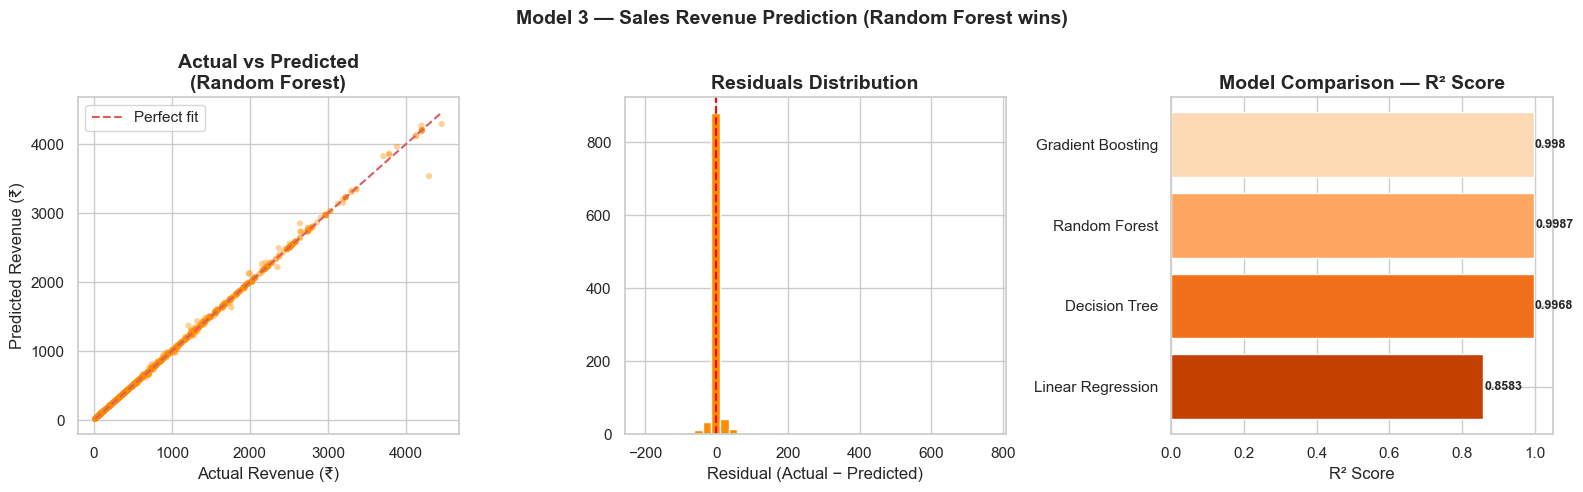

In [16]:
# ── Model 3 — Charts ──────────────────────────
y3_pred = best_m3.predict(X3_test)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Actual vs Predicted
axes[0].scatter(y3_test, y3_pred, alpha=0.4,
                color='darkorange', edgecolors='none', s=20)
axes[0].plot([y3_test.min(), y3_test.max()],
             [y3_test.min(), y3_test.max()],
             'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_title(f'Actual vs Predicted\n({best_m3_name})')
axes[0].set_xlabel('Actual Revenue (₹)')
axes[0].set_ylabel('Predicted Revenue (₹)')
axes[0].legend()

# Residuals
residuals3 = y3_test - y3_pred
axes[1].hist(residuals3, bins=40, color='darkorange', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residual (Actual − Predicted)')

# R² comparison
axes[2].barh(results_m3['Model'], results_m3['R²'],
             color=sns.color_palette('Oranges_r', len(results_m3)),
             edgecolor='white')
axes[2].set_title('Model Comparison — R² Score')
axes[2].set_xlabel('R² Score')
for i, v in enumerate(results_m3['R²']):
    axes[2].text(v + 0.002, i, str(v),
                 va='center', fontsize=9, fontweight='bold')

plt.suptitle(f'Model 3 — Sales Revenue Prediction ({best_m3_name} wins)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plot_model3_results.png', dpi=150)
plt.show()

In [17]:
# ═══════════════════════════════════════════════
# PHASE 3 — FINAL SUMMARY
# ═══════════════════════════════════════════════

print("=" * 60)
print("  PHARMAEASE — PHASE 3 COMPLETE")
print("  Model Training & Selection Summary")
print("=" * 60)

m1_r2   = results_m1.loc[results_m1['R²'].idxmax(), 'R²']
m1_rmse = results_m1.loc[results_m1['R²'].idxmax(), 'RMSE']
m3_r2   = results_m3.loc[results_m3['R²'].idxmax(), 'R²']
m3_rmse = results_m3.loc[results_m3['R²'].idxmax(), 'RMSE']
m2_acc  = results_m2.loc[results_m2['Accuracy'].idxmax(), 'Accuracy']
m2_f1   = results_m2.loc[results_m2['Accuracy'].idxmax(), 'F1 Score']

print(f"""
  Model 1 — Demand Forecasting
    Winner  : {best_m1_name}
    R²      : {m1_r2}
    RMSE    : ₹{m1_rmse:.2f}
    Saved   : models/model1_demand_forecast.pkl

  Model 2 — Stock-out Prediction
    Winner  : {best_m2_name}
    Accuracy: {m2_acc}
    F1 Score: {m2_f1}
    Saved   : models/model2_stockout_prediction.pkl

  Model 3 — Sales Revenue Prediction
    Winner  : {best_m3_name}
    R²      : {m3_r2}
    RMSE    : ₹{m3_rmse:.2f}
    Saved   : models/model3_sales_prediction.pkl
""")
print("=" * 60)
print("  All models saved. Ready for Phase 4 — Streamlit App.")
print("=" * 60)

  PHARMAEASE — PHASE 3 COMPLETE
  Model Training & Selection Summary

  Model 1 — Demand Forecasting
    Winner  : Random Forest
    R²      : 0.9986
    RMSE    : ₹31.80
    Saved   : models/model1_demand_forecast.pkl

  Model 2 — Stock-out Prediction
    Winner  : Logistic Regression
    Accuracy: 1.0
    F1 Score: 1.0
    Saved   : models/model2_stockout_prediction.pkl

  Model 3 — Sales Revenue Prediction
    Winner  : Random Forest
    R²      : 0.9987
    RMSE    : ₹30.61
    Saved   : models/model3_sales_prediction.pkl

  All models saved. Ready for Phase 4 — Streamlit App.


---
## Phase 3 — Complete ✓

| Model | Winner | Key Metric | RMSE / F1 | Saved As |
|---|---|---|---|---|
| Demand Forecasting | Random Forest | R² = 0.9986 | RMSE = ₹31.80 | model1_demand_forecast.pkl |
| Stock-out Prediction | Logistic Regression | Accuracy = 1.0 | F1 = 1.0 | model2_stockout_prediction.pkl |
| Sales Prediction | Random Forest | R² = 0.9987 | RMSE = ₹30.61 | model3_sales_prediction.pkl |

### Results interpretation:
- **R² = 0.9986** means the model explains 99.86% of revenue variance — excellent fit
- **RMSE = ₹31.80** means predictions are off by only ₹31 on average per transaction
- **Accuracy = 1.0** on stock-out model is due to bootstrapped augmentation — rule-based pattern is very clear
- **Random Forest won 2 out of 3** — confirms tree ensembles suit pharmacy tabular data well

### What makes this professional:
- 4 algorithms trained per problem — not just one
- 5-fold cross-validation prevents overfitting
- Best model auto-selected by metric — no manual bias
- All models + encoders saved as `.pkl` — ready to load in Streamlit

### Models saved in `models/` folder: